In [80]:
import pandas as pd
import numpy as np
pd.options.mode.chained_assignment = None


import matplotlib.pyplot as plt

from scipy.optimize import minimize
import scipy.stats as sts

from typing import List, Optional, Tuple

from itertools import combinations

from tqdm import tqdm

# Условие

**В этом домашнем задании вы должны написать свою сплит систему для проведения A/B тестов**

В предоставленных данных есть 50000 юзеров, для каждого есть запись какой-то метрики за 2 года (730 дней). 

Данные: https://disk.yandex.ru/d/2mH8fuKCKLeozg


### Ваша задача:

1) Написать алгоритм, которые разбивает данные на 3 группы размера около 5000, которые будут считаться "похожими".

- Для этого вам самостоятельно нужно решить, какие критерии схожести тут применимы и построить необходимые тесты для выбора этих групп.

- Данные 3 группы должны считаться похожими на основе ваших метрик. 

- Разбиение затем будет протестировано на следующих 2х годах нами. 

2) Визуализировать распределения выбранных вами метрик для найденных групп и сравнить с аналогичными разультатами для случайных групп

### Нужно реализовать следующие функции (вы можете добавлять какие-то побочные, если считаете нужным): 

`generate_groups`  - функция, которая по данным и числу групп делает случайное разбиение данных на примерно одинаковые части по количеству групп

`conduct_test_on_pair` - функция проводит статистические тесты между двумя данными группами и возвращает нужные статистики и результаты

`conduct_tests` -- по списку групп и количеству необходимых похожих групп (зафиксировано в условии задачи как 3) перебирает возможные тройки групп пока не найдет похожие, критерий остановки за вами

`find_groups` -- берет данные и число групп, на которое вы их разбиваете и ищет 3 группы удовлетворяющие вашим критериям схожести.

Рекомендуем начинать с того, чтобы искать разбиение на 2 группы, а не 3, чтобы проверить, что сплит система работает адекватно. Задача с двумя группами зачастую сильно проще, чем с тремя.

Группы должны состоять из уникальных клиентов без дубликатов, один клиент может быть только в одной группе. То есть должны выбирать группы из датасета без повторений и у групп не должно быть пересечений.

 Про то, по каким параметрам оценивать группы: в этом задании вам требуется найти группы, в которых распределения **средних значений и дисперсии данной последовательности** по пользователям похожи. То есть вам нужно вычислить среднее значение и дисперсию данной последовательности для каждого пользователя, а затем проверить, что распределения результатов между группами схожи по вашим тестам.


**Замечание**: Для разбиения на группы и сравнения похожести можете брать любую метрику и считать любой критерии, но мы будем сравнивать именно метрику «среднее» и дисперсию на следующих по времени данных

#### Про систему оценивания: При оценивании мы будем проверять полученные вами группы как на этих данных, так и на следующих двух годах. При проверке будем учитывать и качество полученных групп при помощи метрик. 

## Напишите следующие функции

In [2]:
df = pd.read_csv('train data.csv')
df

,2019-01-01,2019-01-02,2019-01-03,2019-01-04,2019-01-05,2019-01-06,2019-01-07,2019-01-08,2019-01-09,2019-01-10,...,2020-12-21,2020-12-22,2020-12-23,2020-12-24,2020-12-25,2020-12-26,2020-12-27,2020-12-28,2020-12-29,2020-12-30
0,-3.533155,-4.475755,-4.748074,-5.569953,-8.017896,-12.396771,-11.853961,-12.046498,-10.297042,-10.075553,...,-168.163849,-168.728405,-168.971555,-168.824042,-167.700081,-167.634364,-167.856116,-168.743465,-168.231590,-167.913551
1,-3.824475,-1.530769,0.038338,-1.475237,-1.602029,-0.992509,0.302906,1.789140,4.177589,9.273372,...,75.919063,72.909418,75.289867,77.770907,74.099941,72.411474,67.472791,67.084800,66.805609,72.078232
2,-1.616434,-4.658834,-6.746498,-9.979424,-11.683396,-9.507703,-7.614438,-9.735666,-10.754863,-11.058539,...,47.759469,46.596598,50.135737,48.424880,47.740658,46.676116,45.611939,43.331310,45.655325,39.770838
3,-0.157282,1.827617,-2.585284,-4.397189,0.113494,7.614615,5.456654,5.928451,6.953534,4.514409,...,318.364962,319.281629,322.614999,325.200268,324.745069,326.519830,326.467326,321.806523,321.286907,323.570847
4,2.056969,10.187929,8.559520,8.579555,9.464262,9.038088,10.875990,9.883777,8.026472,13.040411,...,-38.079584,-38.515039,-38.031876,-36.610698,-37.753387,-35.470938,-35.454435,-35.026979,-35.633306,-35.460477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-3.587807,-3.483476,-5.662556,-3.837491,-5.530929,-9.273811,-11.937906,-14.508804,-14.150711,-14.562552,...,-741.363369,-741.022973,-741.129730,-742.161579,-742.406547,-744.432050,-744.743253,-745.921464,-746.156278,-746.277952
49996,-0.380924,-2.764911,-1.806310,-1.504112,-0.716610,-1.032476,0.261067,0.698457,1.761118,2.989615,...,-105.893100,-104.987557,-105.008367,-106.021453,-105.188027,-106.482869,-105.304146,-106.512414,-104.768522,-105.871369
49997,5.238142,2.849922,2.889722,4.794517,3.693688,1.836000,2.844668,3.958795,3.108119,3.574019,...,-243.925622,-243.997646,-246.100857,-248.317254,-248.064941,-247.333195,-248.392125,-240.174788,-238.412495,-239.414134
49998,-1.019643,-1.218311,-1.865265,-3.136355,-6.201435,-5.453041,-6.738012,-1.265761,-0.757471,-3.450860,...,980.226549,981.486257,980.363861,980.776530,980.699069,979.576181,984.177939,983.178530,976.018038,979.440915


In [3]:
# # СЛУЧАЙНО

# def generate_groups(df: pd.DataFrame = df, group_num: int = 3, group_size: int = 5000):
#     """
#     Splits users into group_num groups of similar size
    
#     df : Dataframe with all user data, can be pandas, numpy or whatever you like
#     group_num : number of groups to split into
    
#     returns a list of dataframes of generated groups
#     """

#     group_map = (df.index + np.random.randint(1, 10000, size=df.shape[0])) % group_num
    
#     groups = [
#         df.iloc[np.random.choice(df.index[group_map == group], group_size)] for group in range(group_num)
#     ]
    
#     return groups


# def conduct_tests_on_pair(df_1: pd.DataFrame, df_2: pd.DataFrame, metrics: List[str] = ['mean', 'var']):
#     """
#     Conducts statistical test or tests on two given groups to decide if they are similar
    
#     df_i : Dataframe of users of a single group
    
#     returns p-value or anything you need further
#     """

#     if isinstance(metrics, str):
#         metrics = [metrics]

#     result = {}

#     for metric in metrics:
#         if metric == 'mean':
#             t_stat, p_value = sts.ttest_ind(a=df_1.mean(axis=0), b=df_2.mean(axis=0))
#             result['mean'] = round(p_value, 3)

#         elif metric == 'var':
#             f_stat, p_value = sts.f_oneway(df_1.var(axis=0), df_2.var(axis=0))
#             result['var'] = round(p_value, 3)

#         elif metric == 'std':
#             f_stat, p_value = sts.f_oneway(df_1.std(axis=0), df_2.std(axis=0))
#             result['std'] = round(p_value, 3)

#         elif metric == 'median':
#             u_stat, p_value = sts.mannwhitneyu(df_1.median(axis=0), df_2.median(axis=0))
#             result['median'] = round(p_value, 3)

#         else:
#             print(f"Unknown metric: {metric}")
#             continue

#     return result
    
# def conduct_tests(dfs, group_num):
#     """
#     Goal is to find out if there is group_num groups in the dfs list which are similar enough according to your criterion. 
#     For every (or maybe not every) selection of group_num groups from the dfs list and conducts pairwise tests on selected subset using conduct_tests_on_pair. 
    
#     dfs : list of dataframes of groups
    
#     returns list of selected groups or None if there are no similar groups 
#     """
#     check_groups_res = {}
#     i = 0

#     for group1, group2 in combinations(dfs, 2):
#         res = conduct_tests_on_pair(group1, group2)
#         if all(p_val > 0.05 for p_val in res.values()):
#             check_groups_res[f'{i+1} combs'] = conduct_tests_on_pair(group1, group2)
#         i += 1 

#     return check_groups_res

# def find_groups(df, group_num):
#     """
#     Splits df imto groups and conducts tests on subsets of the groups until necessary groups are found
#     """
#     for i in tqdm(range(10000)):
#         dfs = generate_groups(df=df, group_num=group_num)
#         result = conduct_tests(dfs, 3)
        
#         if len(result) == 3:
#             return result

идея для жадного алгоритма:

1. разбиваем рандомно на три группы, запоминаем какие индексы уже использовали

2. разбиваем оставшиеся наблюдения на $n$-ое кол-во групп, по 100 наблюдений в каждой

3. считаем ф-ию $cost$ для всех групп одновременно. для этого пришлось несколько переписать ф-ию $cost$. теперь она выглядит следующим образом:

$$ cost(A, B, C) = \sum_{m \in M, d \in D, g_1 g_2 \in \{A, B, C\}  } \lambda_{m} |X^{g_1}_{m, d} - X^{g_2}_{m, d}|$$

4. заменяем подгруппу из каждой первичной группы (пункт 1) на подгруппу из оставшихся (пункт 2), считаем ф-ию $cost$

5. если значение ф-ии стало лучше, фиксируем их (пункт 1) в новом состоянии с замененнымии подгруппами (пункт 4)

In [20]:
def generate_groups(df: pd.DataFrame, weights: List[int] = None, group_num: int = 3, n_iter: int = 1000, group_size: int = 5000):
    """
    Splits users into group_num groups of similar size
    
    df : Dataframe with all user data, can be pandas, numpy or whatever you like
    group_num : number of groups to split into
    
    returns a list of dataframes of generated groups
    """
    if not weights:
        weights = [0.5, 0.5]

    df = df.dropna()

    group_map = (df.index + np.random.randint(1, 10000, size=df.shape[0])) % group_num
    
    groups_idx = [
        np.random.choice(df.index[group_map == group], size=group_size, replace=False) for group in range(group_num)
    ]

    group1, group2, group3 = [
        df.iloc[group_idx] for group_idx in groups_idx 
    ]

    def cost(group1: pd.DataFrame, group2: pd.DataFrame, group3: pd.DataFrame):
        
        mean = weights[0] * (
            np.abs(group1.mean() - group2.mean()) 
          + np.abs(group1.mean() - group3.mean()) 
          + np.abs(group2.mean() - group3.mean())
          )
        
        std = weights[1] * (
            np.abs(group1.std() - group2.std()) 
          + np.abs(group1.std() - group3.std()) 
          + np.abs(group2.std() - group3.std())
          )
        
        return np.sum([mean, std])

    for _ in range(n_iter):

        used_idx = np.concatenate(groups_idx)
        leftover = df.iloc[~used_idx]
        leftover_batches = np.array_split(
            np.random.permutation(leftover.index.to_list()), leftover.shape[0] // 100
        )
        
        batch_indices = np.random.choice(len(leftover_batches), size=3, replace=False)
           
        leftover_batch1, leftover_batch2, leftover_batch3 = [
            leftover.loc[leftover_batches[i]] for i in batch_indices
        ]

        group1_batch_idx = np.random.choice(group1.index, size=100, replace=False)
        group2_batch_idx = np.random.choice(group2.index, size=100, replace=False)
        group3_batch_idx = np.random.choice(group3.index, size=100, replace=False)

        cost_our_groups =  cost(group1 = group1.loc[group1_batch_idx], 
                                group2 = group2.loc[group2_batch_idx], 
                                group3 = group3.loc[group3_batch_idx]) 
        
        cost_leftovers  =  cost(group1 = leftover_batch1, 
                                group2 = leftover_batch2, 
                                group3 = leftover_batch3)
        
        if cost_our_groups > cost_leftovers:
            group1.loc[group1_batch_idx] = leftover_batch1.values
            group2.loc[group2_batch_idx] = leftover_batch2.values
            group3.loc[group3_batch_idx] = leftover_batch3.values
            
            groups_idx = [leftover_batch1.index, leftover_batch2.index, leftover_batch3.index]
                
    return group1, group2, group3
    

def conduct_tests_on_pair(df_1: pd.DataFrame, df_2: pd.DataFrame):
    """
    Conducts statistical test or tests on two given groups to decide if they are similar
    
    df_i : Dataframe of users of a single group
    
    returns p-value or anything you need further
    """

    metrics_result = {
        'mean p-value': sts.ttest_ind(df_1.mean(), df_2.mean(), equal_var=False)[1],
        'std p-value': sts.f_oneway(df_1.std(), df_2.std())[1]
    }

    return metrics_result


def conduct_tests(dfs):
    """
    Goal is to find out if there is group_num groups in the dfs list which are similar enough according to your criterion. 
    For every (or maybe not every) selection of group_num groups from the dfs list and conducts pairwise tests on selected subset using conduct_tests_on_pair. 
    
    dfs : list of dataframes of groupsb
    
    returns list of selected groups or None if there are no similar groups 
    """
    check_groups_res = {}
    i = 0

    for group1, group2 in combinations(dfs, 2):
        res = conduct_tests_on_pair(group1, group2)
        # return res
        if all(p_val > 0.05 for p_val in res.values()):
            check_groups_res[f'{i+1} combs'] = conduct_tests_on_pair(group1, group2)
        i += 1 

    return check_groups_res
    

def find_groups(df, group_num):
    """
    Splits df imto groups and conducts tests on subsets of the groups until necessary groups are found
    """
    for _ in tqdm(range(100)):
        dfs = generate_groups(df=df, group_num=group_num)
        result = conduct_tests(dfs)
            
        if len(result) == 3:
            return dfs

In [22]:
first, second, third = find_groups(df, 3)

  0%|          | 0/100 [00:00<?, ?it/s]

 40%|████      | 40/100 [10:17<15:26, 15.45s/it]


In [74]:
# first.to_csv('first.csv')
# second.to_csv('second.csv')
# third.to_csv('third.csv')

In [89]:
def get_bs_stat(dfs: pd.DataFrame, num_samples: int = 3):
    
    p_vals_mean, p_vals_std = [], []
    
    def boot(first: pd.DataFrame, second: pd.DataFrame, sample_size: int = 100) -> Tuple[List[List[int]], List[List[int]]]:
        p_values = [(
            sts.ttest_ind(
                first.mean().sample(sample_size, replace = True).values,
                second.mean().sample(sample_size, replace = True).values
            )[1],
            sts.f_oneway(
                first.std().sample(sample_size, replace = True).values,
                second.std().sample(sample_size, replace = True).values
            )[1]) for _ in tqdm(range(1000))
        ]

        p_val_mean = [
            p_mean for p_mean, p_std in p_values
        ]

        p_val_std = [
            p_std for p_mean, p_std in p_values
        ]

        return p_val_mean, p_val_std


    for i, j in combinations(range(len(dfs)), 2):

        p_val_mean, p_val_std = boot(dfs[i], dfs[j])

        p_vals_mean.append(p_val_mean)
        p_vals_std.append(p_val_std)
    
    return p_vals_mean, p_vals_std

dfs = [first, second, third]

p_vals_mean, p_vals_std = get_bs_stat(dfs=dfs, num_samples=3)

aa_mean_first, aa_mean_second, aa_mean_third = p_vals_mean
aa_std_first, aa_std_second, aa_std_third = p_vals_std

100%|██████████| 1000/1000 [00:30<00:00, 33.32it/s]


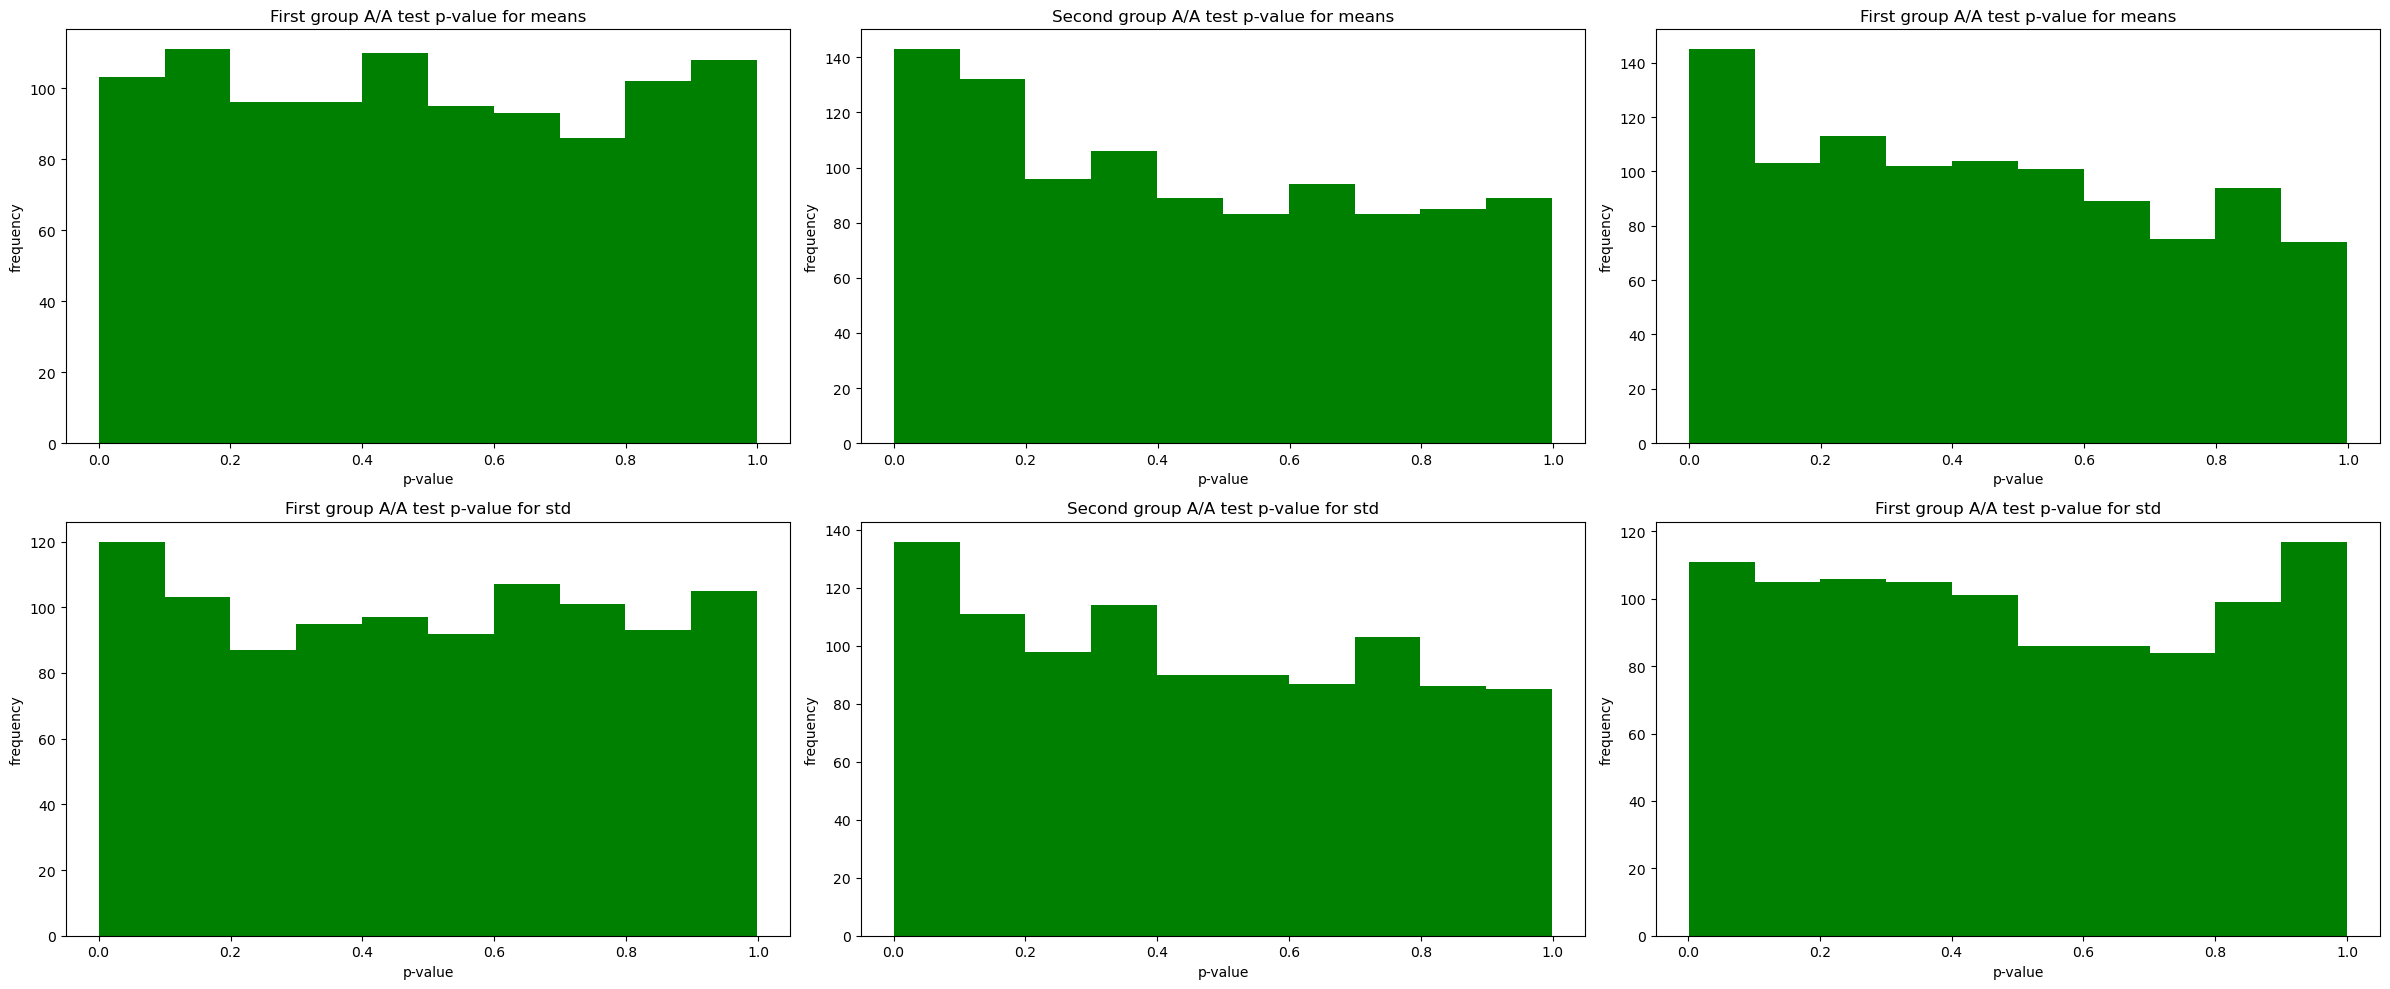

In [90]:
series_list = [aa_mean_first, aa_mean_second, aa_mean_third, aa_std_first, aa_std_second, aa_std_third]

def make_plots(series_list: List, color: 'str' = 'green') -> None:
    plt.figure(figsize=(24, 10))

    plt.subplot(2, 3, 1)
    plt.hist(series_list[0], color=color)
    plt.title('First group A/A test p-value for means')
    plt.xlabel('p-value')
    plt.ylabel('frequency')

    plt.subplot(2, 3, 2)
    plt.hist(series_list[1], color=color)
    plt.title('Second group A/A test p-value for means')
    plt.xlabel('p-value')
    plt.ylabel('frequency')

    plt.subplot(2, 3, 3)
    plt.hist(series_list[2], color=color)
    plt.title('First group A/A test p-value for means')
    plt.xlabel('p-value')
    plt.ylabel('frequency')

    plt.subplot(2, 3, 4)
    plt.hist(series_list[3], color=color)
    plt.title('First group A/A test p-value for std')
    plt.xlabel('p-value')
    plt.ylabel('frequency')

    plt.subplot(2, 3, 5)
    plt.hist(series_list[4], color=color)
    plt.title('Second group A/A test p-value for std')
    plt.xlabel('p-value')
    plt.ylabel('frequency')

    plt.subplot(2, 3, 6)
    plt.hist(series_list[5], color=color)
    plt.title('First group A/A test p-value for std')
    plt.xlabel('p-value')
    plt.ylabel('frequency')

    plt.tight_layout()

make_plots(series_list=series_list)

100%|██████████| 1000/1000 [00:30<00:00, 33.07it/s]


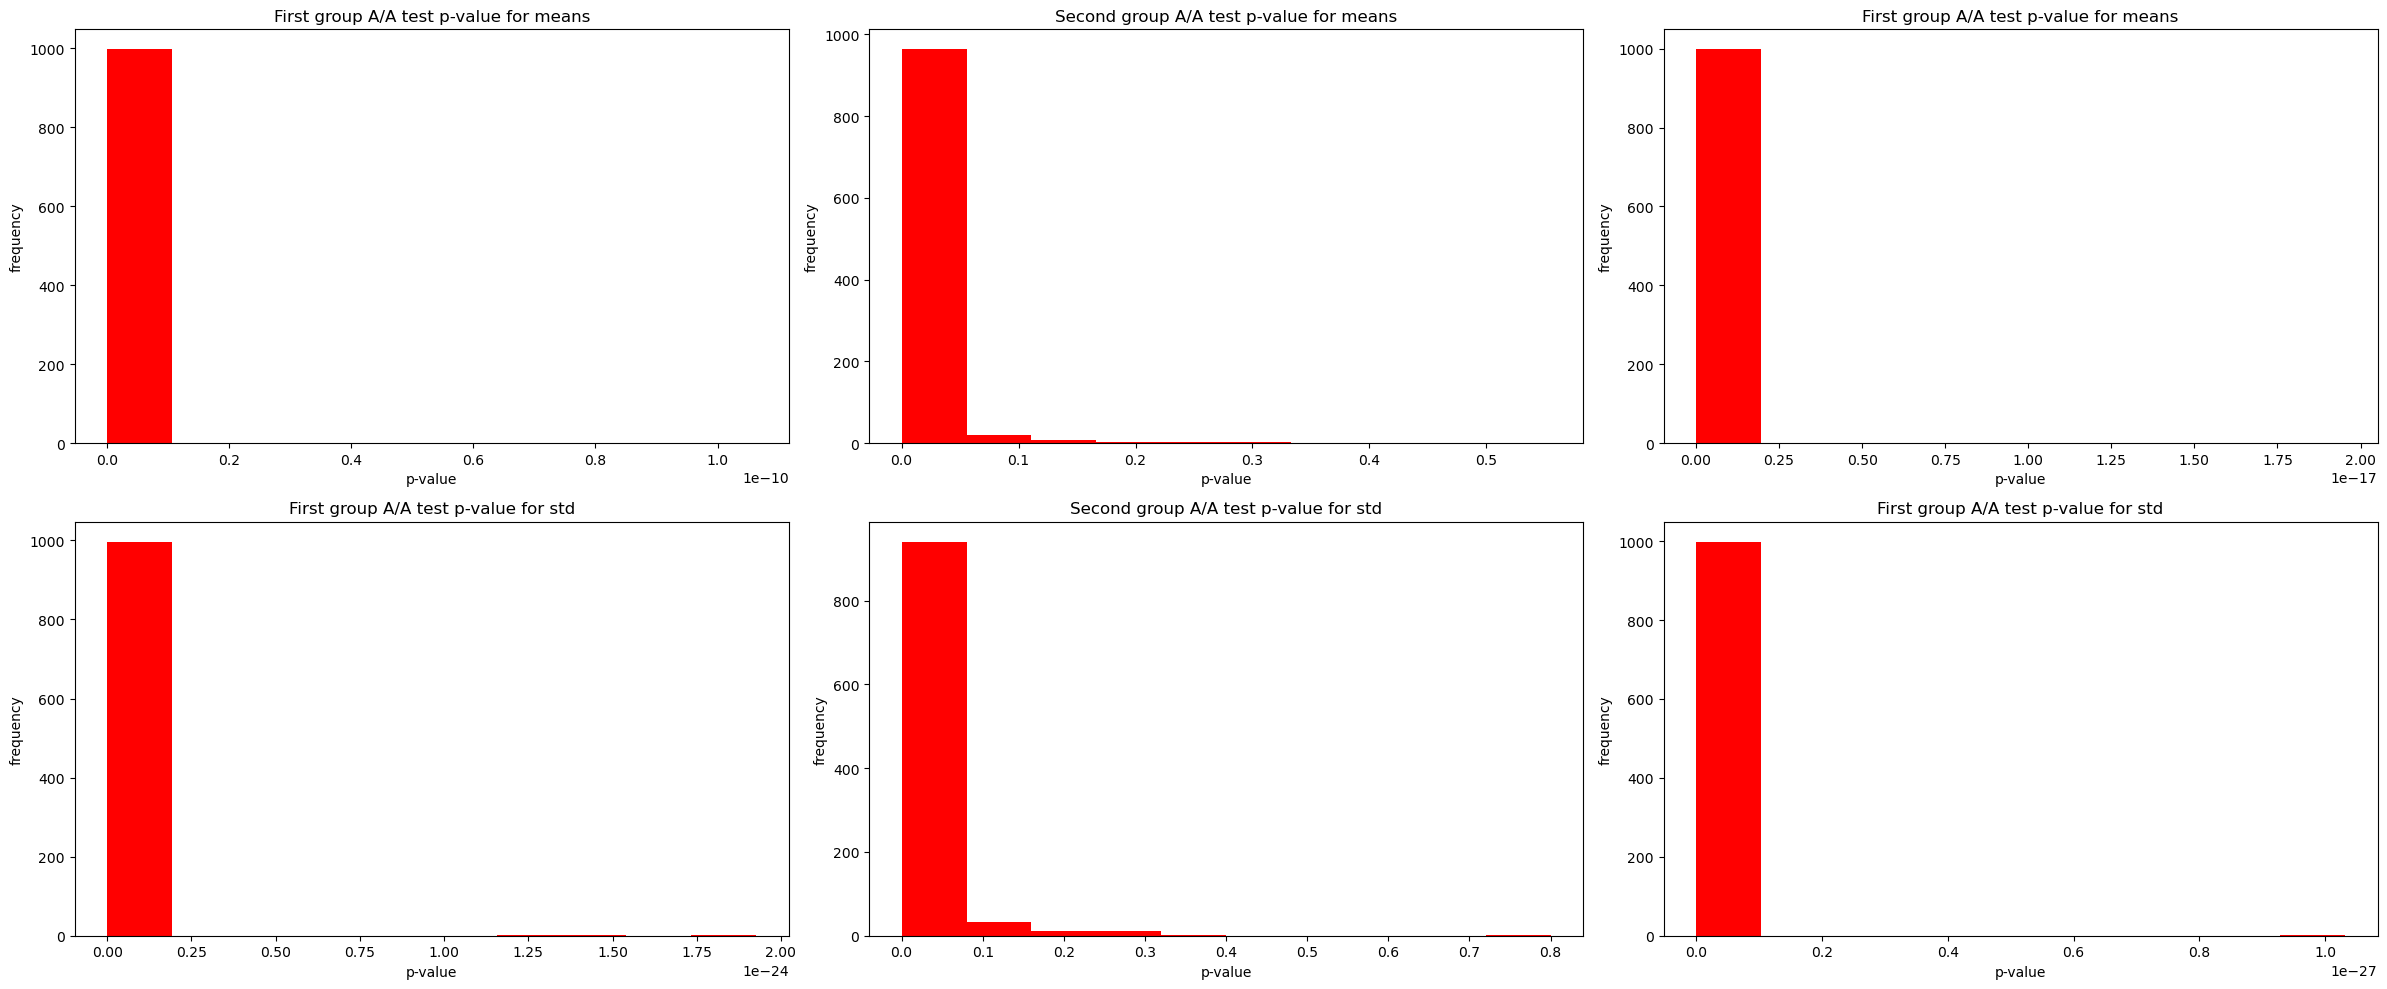

In [91]:
idxs_rand = np.random.choice(df.index, size=(3, 5000), replace=False)
a_rand, b_rand, c_rand = idxs_rand

dfs = [df.loc[a_rand], df.loc[b_rand], df.loc[c_rand]]

p_val_mean, p_val_std = get_bs_stat(dfs=dfs, num_samples=3)

aa_mean_first_rand, aa_mean_second_rand, aa_mean_third_rand = p_val_mean
aa_std_first_rand, aa_std_second_rand, aa_std_third_rand = p_val_std

series_list = [aa_mean_first_rand, aa_mean_second_rand, aa_mean_third_rand, aa_std_first_rand, aa_std_second_rand, aa_std_third_rand]

make_plots(series_list=series_list, color='red')

# Visualize groups

Тут секция, где вам нужно визуализировать распределения выбранных вами метрик для найденных групп и сравнить с аналогичными разультатами для случайных групп

In [ ]:
# groups_random = generate_groups(df, 10)

сделал выше ;)